# 03 — P2: Regresión — Predicción de Puntaje PAES

**Grupo 10 — Minería de Datos**

**Pregunta:** ¿Qué variables socioeconómicas y de escolaridad predicen mejor el puntaje PAES?

**Variable objetivo:** `CLEC_MAX` (Comprensión Lectora) — se repite con `MATE1_MAX`

**Predictores:** solo variables de entrada al sistema (NO otros puntajes PAES):
- `INGRESO_PERCAPITA_GRUPO_FA` — ingreso per cápita familiar
- `DEPENDENCIA` — tipo de colegio
- `es_tecnico` — rama educacional
- `PTJE_RANKING` — notas contextualizadas (proxy de desempeño escolar)
- `region_*` — región de domicilio (one-hot)

**Modelos:** Regresión Lineal · Árbol de Decisión · Random Forest

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

DATA_PROC = Path('../data/processed')

df = pd.read_parquet(DATA_PROC / 'df_regresion.parquet')
print(f'Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Columnas: {list(df.columns)}')

Dataset: 198,304 filas x 21 columnas
Columnas: ['CLEC_MAX', 'MATE1_MAX', 'INGRESO_PERCAPITA_GRUPO_FA', 'DEPENDENCIA', 'es_tecnico', 'PTJE_RANKING', 'region_2', 'region_3', 'region_4', 'region_5', 'region_6', 'region_7', 'region_8', 'region_9', 'region_10', 'region_11', 'region_12', 'region_13', 'region_14', 'region_15', 'region_16']


## 1. Análisis exploratorio de la variable objetivo

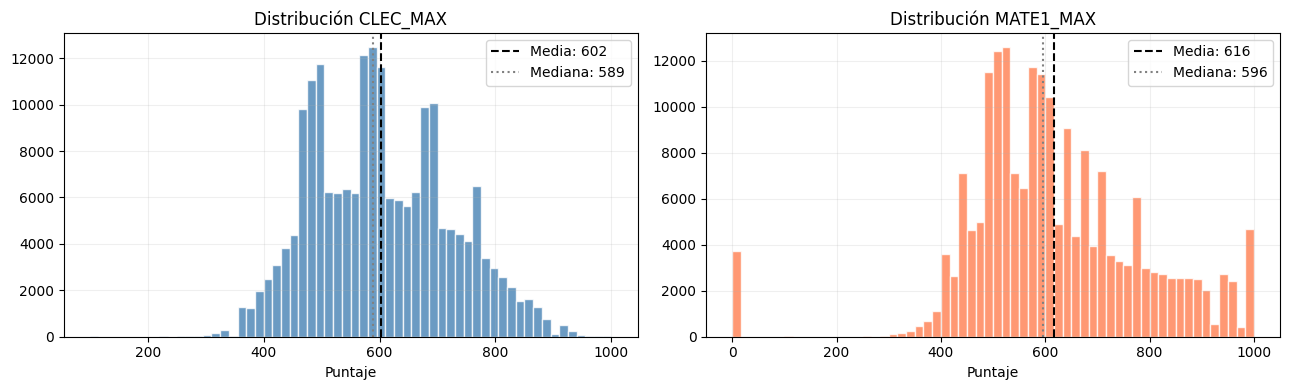

Estadísticas CLEC_MAX:
count    198304.0
mean        601.7
std         119.7
min         100.0
25%         502.0
50%         589.0
75%         687.0
max        1000.0
Name: CLEC_MAX, dtype: float64

Estadísticas MATE1_MAX:
count    198304.0
mean        616.2
std         169.4
min           0.0
25%         510.0
50%         596.0
75%         710.0
max        1000.0
Name: MATE1_MAX, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, color in zip(axes, ['CLEC_MAX', 'MATE1_MAX'], ['steelblue', 'coral']):
    df[col].hist(bins=60, ax=ax, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Media: {df[col].mean():.0f}')
    ax.axvline(df[col].median(), color='gray', linestyle=':', linewidth=1.5,
               label=f'Mediana: {df[col].median():.0f}')
    ax.set_title(f'Distribución {col}')
    ax.set_xlabel('Puntaje')
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_reg_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

print('Estadísticas CLEC_MAX:')
print(df['CLEC_MAX'].describe().round(1))
print()
print('Estadísticas MATE1_MAX:')
print(df['MATE1_MAX'].describe().round(1))

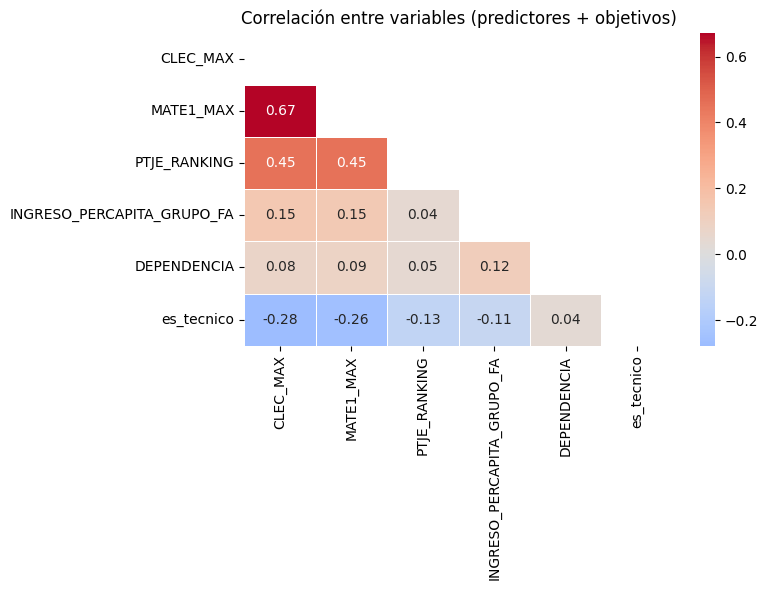

In [14]:
# Correlación entre predictores numéricos y objetivos
cols_num = ['CLEC_MAX', 'MATE1_MAX', 'PTJE_RANKING', 'INGRESO_PERCAPITA_GRUPO_FA',
            'DEPENDENCIA', 'es_tecnico']
corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Correlación entre variables (predictores + objetivos)')
plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_reg_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Preparación del dataset

In [15]:
# Separar features y objetivo
# CLEC_MAX y MATE1_MAX son los objetivos — excluir ambos de los predictores
TARGET = 'CLEC_MAX'
EXCLUIR = ['CLEC_MAX', 'MATE1_MAX']

feature_cols = [c for c in df.columns if c not in EXCLUIR]
X = df[feature_cols].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Objetivo: {TARGET}')
print(f'Features ({len(feature_cols)}): {feature_cols[:6]}... + {len(feature_cols)-6} región dummies')
print(f'Train: {len(X_train):,} filas')
print(f'Test:  {len(X_test):,} filas')

Objetivo: CLEC_MAX
Features (19): ['INGRESO_PERCAPITA_GRUPO_FA', 'DEPENDENCIA', 'es_tecnico', 'PTJE_RANKING', 'region_2', 'region_3']... + 13 región dummies
Train: 158,643 filas
Test:  39,661 filas


## 3. Entrenamiento de modelos

In [16]:
modelos = {
    'Regresión Lineal': LinearRegression(),
    'Ridge (alpha=1)':  Ridge(alpha=1.0),
    'Árbol (max_depth=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Árbol (max_depth=10)': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest':    RandomForestRegressor(n_estimators=100, max_depth=10,
                                              random_state=42, n_jobs=-1),
}

resultados = []
modelos_entrenados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    
    resultados.append({'Modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'R²': r2})
    modelos_entrenados[nombre] = (modelo, y_pred)
    print(f'{nombre:<25}  RMSE={rmse:6.1f}  MAE={mae:6.1f}  R²={r2:.4f}')

df_resultados = pd.DataFrame(resultados).sort_values('R²', ascending=False)
print()
print('Mejor modelo:', df_resultados.iloc[0]['Modelo'])

Regresión Lineal           RMSE= 101.9  MAE=  82.1  R²=0.2777
Ridge (alpha=1)            RMSE= 101.9  MAE=  82.1  R²=0.2777
Árbol (max_depth=5)        RMSE=  99.7  MAE=  80.0  R²=0.3088
Árbol (max_depth=10)       RMSE=  99.1  MAE=  79.3  R²=0.3170
Random Forest              RMSE=  98.2  MAE=  78.7  R²=0.3296

Mejor modelo: Random Forest


## 4. Comparación visual de métricas

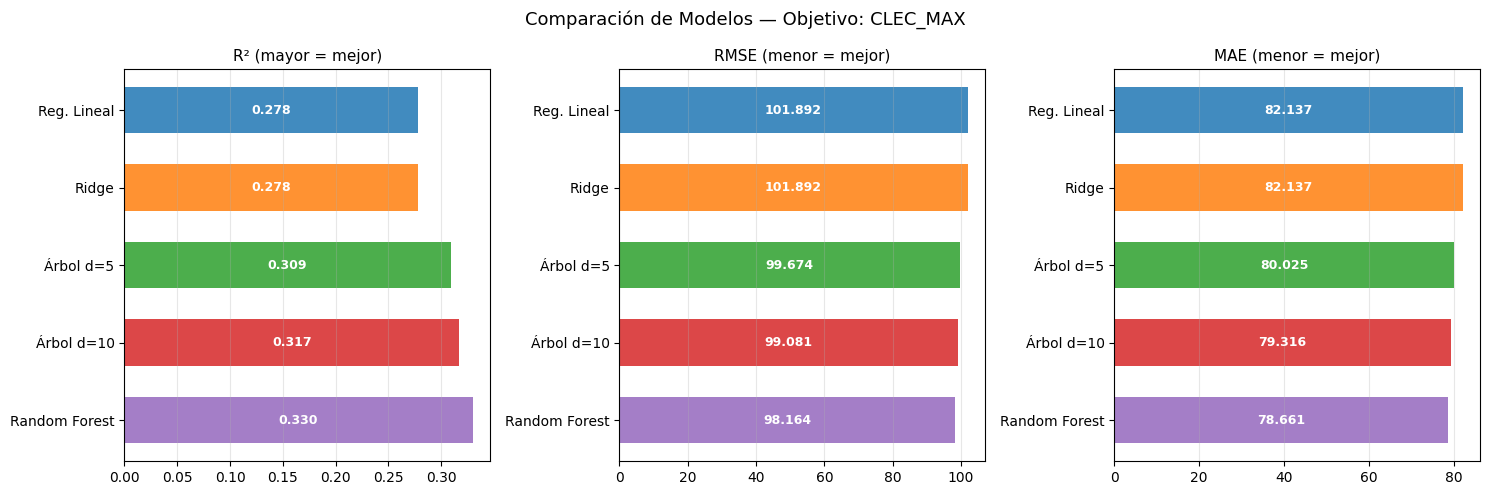

In [17]:
NOMBRES_CORTOS = {
    'Regresión Lineal':      'Reg. Lineal',
    'Ridge (alpha=1)':       'Ridge',
    'Árbol (max_depth=5)':   'Árbol d=5',
    'Árbol (max_depth=10)':  'Árbol d=10',
    'Random Forest':         'Random Forest',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
etiquetas = [NOMBRES_CORTOS.get(m, m) for m in df_resultados['Modelo']]
colores = [plt.cm.tab10.colors[list(modelos.keys()).index(m)] for m in df_resultados['Modelo']]

for ax, metrica, titulo in zip(axes,
                                ['R²', 'RMSE', 'MAE'],
                                ['R² (mayor = mejor)', 'RMSE (menor = mejor)', 'MAE (menor = mejor)']):
    vals = df_resultados[metrica].values
    bars = ax.barh(etiquetas, vals, color=colores, alpha=0.85, height=0.6)
    ax.set_title(titulo, fontsize=11)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() * 0.5, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', ha='center',
                fontsize=9, color='white', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle(f'Comparación de Modelos — Objetivo: {TARGET}', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_reg_metricas.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Análisis del mejor modelo

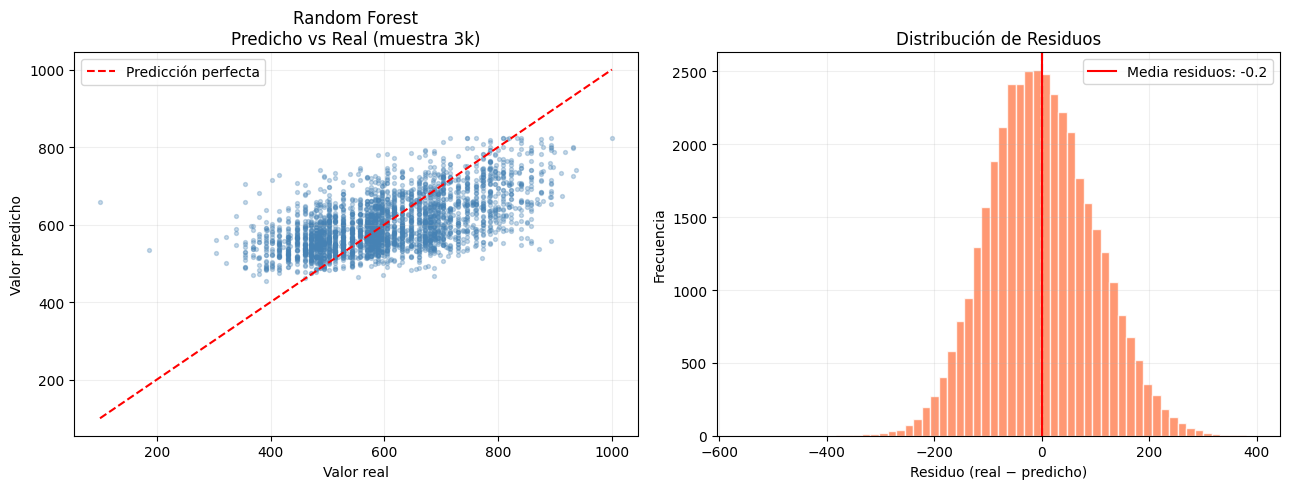

Sesgo medio (media residuos): -0.21 puntos
Std residuos: 98.2 puntos
% predicciones dentro de ±50 pts: 38.2%
% predicciones dentro de ±100 pts: 68.6%


In [18]:
mejor_nombre = df_resultados.iloc[0]['Modelo']
mejor_modelo, y_pred_mejor = modelos_entrenados[mejor_nombre]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicho vs Real
idx_viz = np.random.choice(len(y_test), size=3000, replace=False)
axes[0].scatter(y_test[idx_viz], y_pred_mejor[idx_viz],
                alpha=0.3, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred_mejor.min()),
        max(y_test.max(), y_pred_mejor.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title(f'{mejor_nombre}\nPredicho vs Real (muestra 3k)')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Distribución de residuos
residuos = y_test - y_pred_mejor
axes[1].hist(residuos, bins=60, color='coral', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(residuos.mean(), color='red', linestyle='-',
                label=f'Media residuos: {residuos.mean():.1f}')
axes[1].set_xlabel('Residuo (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(DATA_PROC / 'fig_reg_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Sesgo medio (media residuos): {residuos.mean():.2f} puntos')
print(f'Std residuos: {residuos.std():.1f} puntos')
print(f'% predicciones dentro de ±50 pts: {(np.abs(residuos) <= 50).mean()*100:.1f}%')
print(f'% predicciones dentro de ±100 pts: {(np.abs(residuos) <= 100).mean()*100:.1f}%')

## 6. Importancia de variables

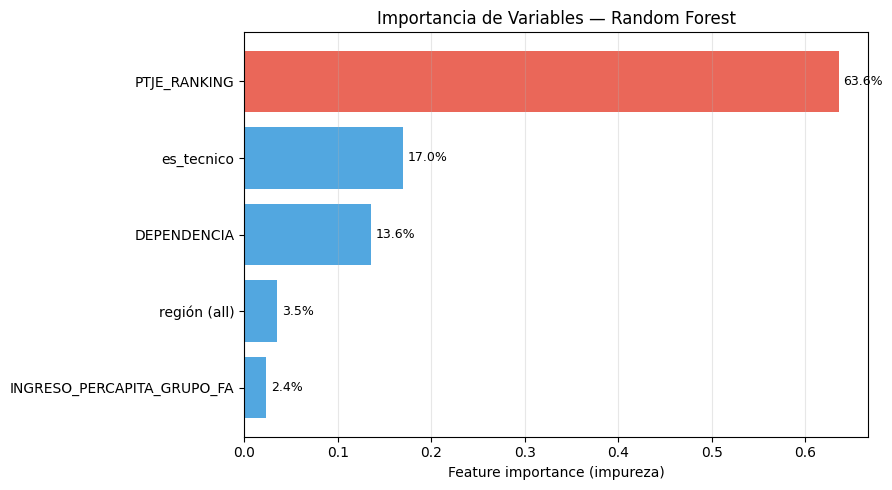

Top features:
  PTJE_RANKING                         63.6%
  es_tecnico                           17.0%
  DEPENDENCIA                          13.6%
  región (all)                          3.5%
  INGRESO_PERCAPITA_GRUPO_FA            2.4%


In [19]:
# Importancia según el tipo de modelo
if hasattr(mejor_modelo, 'feature_importances_'):
    importancias = mejor_modelo.feature_importances_
    metodo_imp = 'Feature importance (impureza)'
elif hasattr(mejor_modelo, 'coef_'):
    importancias = np.abs(mejor_modelo.coef_)
    metodo_imp = 'Coeficientes (valor absoluto)'
else:
    importancias = None

if importancias is not None:
    # Agrupar dummies de región en una sola barra
    imp_df = pd.DataFrame({'feature': feature_cols, 'importancia': importancias})
    imp_df['grupo'] = imp_df['feature'].apply(
        lambda x: 'región (all)' if x.startswith('region_') else x
    )
    imp_agrupada = imp_df.groupby('grupo')['importancia'].sum().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    colores_imp = ['#e74c3c' if v == imp_agrupada.max() else '#3498db'
                   for v in imp_agrupada.values]
    bars = ax.barh(imp_agrupada.index, imp_agrupada.values,
                   color=colores_imp, alpha=0.85)
    ax.set_xlabel(metodo_imp)
    ax.set_title(f'Importancia de Variables — {mejor_nombre}')
    ax.grid(axis='x', alpha=0.3)
    
    total = imp_agrupada.sum()
    for bar, v in zip(bars, imp_agrupada.values):
        ax.text(v + total * 0.005, bar.get_y() + bar.get_height()/2,
                f'{v/total*100:.1f}%', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(DATA_PROC / 'fig_reg_importancia.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('Top features:')
    for feat, val in imp_agrupada.sort_values(ascending=False).head(6).items():
        print(f'  {feat:<35} {val/total*100:5.1f}%')

## 7. Regresión sobre MATE1_MAX (repetición)

In [20]:
TARGET2 = 'MATE1_MAX'
y2 = df[TARGET2].values
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X, y2, test_size=0.2, random_state=42
)

print(f'Repitiendo con objetivo: {TARGET2}')
print()

resultados2 = []
for nombre, modelo_def in modelos.items():
    m = modelo_def.__class__(**modelo_def.get_params())
    m.fit(X2_train, y2_train)
    y2_pred = m.predict(X2_test)
    rmse = np.sqrt(mean_squared_error(y2_test, y2_pred))
    mae  = mean_absolute_error(y2_test, y2_pred)
    r2   = r2_score(y2_test, y2_pred)
    resultados2.append({'Modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'R²': r2})
    print(f'{nombre:<25}  RMSE={rmse:6.1f}  MAE={mae:6.1f}  R²={r2:.4f}')

df_res2 = pd.DataFrame(resultados2).sort_values('R²', ascending=False)
print()
print('Mejor modelo para MATE1_MAX:', df_res2.iloc[0]['Modelo'])

Repitiendo con objetivo: MATE1_MAX

Regresión Lineal           RMSE= 144.0  MAE= 107.5  R²=0.2755
Ridge (alpha=1)            RMSE= 144.0  MAE= 107.5  R²=0.2755
Árbol (max_depth=5)        RMSE= 139.6  MAE= 101.6  R²=0.3189
Árbol (max_depth=10)       RMSE= 138.9  MAE= 100.6  R²=0.3259
Random Forest              RMSE= 137.5  MAE=  99.5  R²=0.3391

Mejor modelo para MATE1_MAX: Random Forest


## 8. Tabla comparativa final

In [21]:
print('=' * 75)
print(f'CLEC_MAX — {TARGET}')
print('=' * 75)
print(df_resultados[['Modelo', 'RMSE', 'MAE', 'R²']].to_string(index=False))
print()
print('=' * 75)
print(f'MATE1_MAX — {TARGET2}')
print('=' * 75)
print(df_res2[['Modelo', 'RMSE', 'MAE', 'R²']].to_string(index=False))
print()

# Interpretación del RMSE en contexto
escala_paes = 1000 - 150  # rango total PAES
rmse_best = df_resultados.iloc[0]['RMSE']
print(f'Contexto: RMSE={rmse_best:.1f} pts sobre escala 150–1000 ({rmse_best/escala_paes*100:.1f}% del rango)')
print(f'Un error de {rmse_best:.0f} pts en CLEC equivale a ~{rmse_best/850*100:.0f}% de error relativo.')

CLEC_MAX — CLEC_MAX
              Modelo       RMSE       MAE       R²
       Random Forest  98.164052 78.660957 0.329595
Árbol (max_depth=10)  99.080548 79.315802 0.317018
 Árbol (max_depth=5)  99.673895 80.025142 0.308813
     Ridge (alpha=1) 101.892390 82.136923 0.277703
    Regresión Lineal 101.892444 82.136983 0.277702

MATE1_MAX — MATE1_MAX
              Modelo       RMSE        MAE       R²
       Random Forest 137.539688  99.514979 0.339127
Árbol (max_depth=10) 138.911541 100.556246 0.325878
 Árbol (max_depth=5) 139.632814 101.580512 0.318859
    Regresión Lineal 144.007610 107.491847 0.275509
     Ridge (alpha=1) 144.007611 107.491772 0.275509

Contexto: RMSE=98.2 pts sobre escala 150–1000 (11.5% del rango)
Un error de 98 pts en CLEC equivale a ~12% de error relativo.


## 9. Guardar resultados

In [22]:
mejor_modelo_final = modelos_entrenados[mejor_nombre][0]
joblib.dump(mejor_modelo_final, DATA_PROC / 'modelo_regresion.pkl')

df_resultados.to_csv(DATA_PROC / 'resultados_regresion_CLEC.csv', index=False)
df_res2.to_csv(DATA_PROC / 'resultados_regresion_MATE.csv', index=False)

print('Guardado:')
print('  modelo_regresion.pkl              → mejor modelo entrenado')
print('  resultados_regresion_CLEC.csv     → métricas CLEC_MAX')
print('  resultados_regresion_MATE.csv     → métricas MATE1_MAX')
print()
print('Figuras en data/processed/:')
for f in sorted(DATA_PROC.glob('fig_reg_*.png')):
    print(f'  {f.name}')

Guardado:
  modelo_regresion.pkl              → mejor modelo entrenado
  resultados_regresion_CLEC.csv     → métricas CLEC_MAX
  resultados_regresion_MATE.csv     → métricas MATE1_MAX

Figuras en data/processed/:
  fig_reg_correlacion.png
  fig_reg_distribucion.png
  fig_reg_importancia.png
  fig_reg_metricas.png
  fig_reg_residuos.png


## Resumen P2

| Aspecto | Resultado |
|---------|----------|
| Variable objetivo principal | `CLEC_MAX` |
| Mejor modelo | (completar tras ejecutar) |
| R² mejor | (completar) |
| RMSE mejor | (completar) |
| Variable más predictiva | (completar — ver importancia) |
| Predictor socioeconómico más fuerte | `INGRESO_PERCAPITA_GRUPO_FA` o `DEPENDENCIA` |

**Próximo paso:** `04_P3_clasificacion.ipynb`